In [2]:
"""
LangGraph enables the construction of complex, multi-step workflows for language models, and supports parallelization to improve efficiency and throughput. Parallelization in LangGraph allows multiple nodes (tasks) in the workflow graph to execute simultaneously when they are independent of each other. This is particularly useful for scenarios where several operations can be performed concurrently, such as generating multiple responses, running different validation checks, or processing branches of logic in parallel.

**Key Points:**
- **Node Independence:** Nodes without dependencies can be executed in parallel, reducing overall execution time.
- **Concurrency Control:** LangGraph manages the execution order based on the graph structure, ensuring that dependent nodes wait for their prerequisites.
- **Scalability:** Parallel execution is beneficial for large or complex workflows, enabling better resource utilization and faster results.
- **Use Cases:** Parallelization is ideal for tasks like multi-agent collaboration, ensemble model evaluation, or simultaneous data processing.

By leveraging parallelization, LangGraph workflows can be both expressive and performant, making it a powerful tool for orchestrating advanced language model applications.
"""

'\nLangGraph enables the construction of complex, multi-step workflows for language models, and supports parallelization to improve efficiency and throughput. Parallelization in LangGraph allows multiple nodes (tasks) in the workflow graph to execute simultaneously when they are independent of each other. This is particularly useful for scenarios where several operations can be performed concurrently, such as generating multiple responses, running different validation checks, or processing branches of logic in parallel.\n\n**Key Points:**\n- **Node Independence:** Nodes without dependencies can be executed in parallel, reducing overall execution time.\n- **Concurrency Control:** LangGraph manages the execution order based on the graph structure, ensuring that dependent nodes wait for their prerequisites.\n- **Scalability:** Parallel execution is beneficial for large or complex workflows, enabling better resource utilization and faster results.\n- **Use Cases:** Parallelization is ideal

In [7]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("AZURE_OPENAI_API_KEY")
os.environ["OPENAI_ENDPOINT"] = os.getenv("AZURE_OPENAI_ENDPOINT")
os.environ["OPENAI_API_VERSION"] = "2024-12-01-preview"
os.environ["OPENAI_DEPLOYMENT_NAME"] = "gpt-4o"
os.environ["OPENAI_MODEL"] = "gpt-4o"
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_PROJECT"] = os.getenv("LANGSMITH_PROJECT")
os.environ["LANGSMITH_TRACING_V2"] = os.getenv("LANGSMITH_TRACING_V2")

open_api_key = os.getenv("AZURE_OPENAI_API_KEY")
if open_api_key:
    print(f"Azure Open API Key loaded: {open_api_key[:10]}...{open_api_key[-4:]}")
    print(f"Model: {os.getenv('OPENAI_MODEL')}")
    os.environ["OPENAI_API_KEY"] = open_api_key
else:
    print("Azure API Key not found in environment variables")
    print("Available environment variables with 'Azure':", [k for k in os.environ.keys() if 'Azure' in k.upper()])

langsmith_key = os.getenv("LANGSMITH_API_KEY")
if langsmith_key:
    print(f"Langsmith Key loaded: {langsmith_key[:10]}...{langsmith_key[-4:]}")
    print(f"LANGSMITH_PROJECT: {os.getenv('LANGSMITH_PROJECT')}")
    os.environ["LANGSMITH_API_KEY"] = langsmith_key


Azure Open API Key loaded: 1Sttw3VbMy...EzVq
Model: gpt-4o
Langsmith Key loaded: lsv2_pt_41...99ef
LANGSMITH_PROJECT: roadmap-to-ai-ml


In [8]:
from langchain_openai import AzureChatOpenAI
from langchain.schema import HumanMessage, SystemMessage

# Create Azure ChatOpenAI instance
llm = AzureChatOpenAI(
    azure_deployment=os.getenv("OPENAI_DEPLOYMENT_NAME"),   
    api_version=os.getenv("OPENAI_API_VERSION"),            
    azure_endpoint=os.getenv("OPENAI_ENDPOINT"),           
    api_key=os.getenv("OPENAI_API_KEY")
)

print(f"Created Azure ChatOpenAI: {llm}")

Created Azure ChatOpenAI: client=<openai.resources.chat.completions.completions.Completions object at 0x7f6984b59220> async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7f6984c041a0> root_client=<openai.lib.azure.AzureOpenAI object at 0x7f6984c31430> root_async_client=<openai.lib.azure.AsyncAzureOpenAI object at 0x7f6984c04350> model_kwargs={} openai_api_key=SecretStr('**********') disabled_params={'parallel_tool_calls': None} azure_endpoint='https://zama-roadmap-to-aiml.openai.azure.com/' deployment_name='gpt-4o' openai_api_version='2024-12-01-preview' openai_api_type='azure'


In [33]:
response = llm.invoke([
    SystemMessage(content="You are a helpful assistant."),
    HumanMessage(content="What is the capital of India?")
])
response.content

'The capital of India is **New Delhi**.'

In [9]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

class State(TypedDict):
    topic: str
    characters: str
    settings: str
    premises: str
    story_intro: str

def generate_characters(state:State):
    """Generate character descriptions"""
    msg = llm.invoke(f"Create two characters names and brief traits for a story about {state['topic']}")
    return {"characters": msg.content}

def generate_setting(state: State):
    """Generate a story setting"""
    msg = llm.invoke(f"Describe a vivid setting for a story about {state['topic']}")
    return {"settings": msg.content}

def generate_premise(state: State):
    """Generate a story premise"""
    msg = llm.invoke(f"Write a one-sentence plot premise for a story about {state['topic']}")
    return {"premises": msg.content}

def combine_elements(state: State):
    """Combine characters, settings and premises into a story intro"""
    msg = llm.invoke(
        f"Write a short story introduction using these elements: \n"
        f"Characters: {state['characters']}\n"
        f"Setting: {state['settings']}\n"
        f"Premise: {state['premises']}\n"
    )
    return {"story_intro": msg.content}


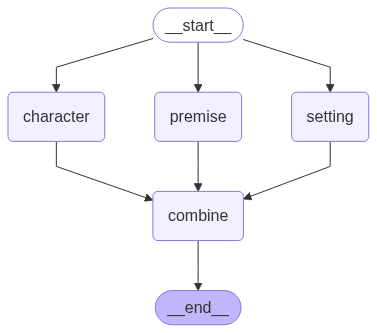

In [11]:
graph = StateGraph(State)

graph.add_node("character", generate_characters)
graph.add_node("premise", generate_premise)
graph.add_node("setting", generate_setting)
graph.add_node("combine", combine_elements)

graph.add_edge(START, "character")
graph.add_edge(START, "premise")
graph.add_edge(START, "setting")
graph.add_edge("character", "combine")
graph.add_edge("premise", "combine")
graph.add_edge("setting", "combine")


compiled_graph = graph.compile()
graph_image = compiled_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))





In [13]:
state = {"topic": "Time travel"}

result = compiled_graph.invoke(state)
result

{'topic': 'Time travel',
 'characters': 'Sure! Here are two characters for your time travel story:  \n\n### 1. **Dr. Elise Voss**\n   - **Traits**: Brilliant, compassionate, and stubbornly curious.\n   - **Profession**: Quantum physicist and reluctant adventurer.  \n   - **Background**: Elise is the genius mind behind the first functional time machine, though she originally designed it as a theoretical model to study the nature of time. Her insatiable curiosity drives her forward, but she struggles with the ethical implications of altering the past or future. Underneath her composed exterior, Elise harbors deep regrets about a personal loss she hopes to one day understand—or fix—using her invention.  \n   - **Conflict**: She is constantly torn between using her technology responsibly and her desire to explore time to uncover forgotten or hidden truths.\n\n---\n\n### 2. **Kian Holt**\n   - **Traits**: Resourceful, street-smart, and a bit sarcastic.  \n   - **Profession**: Former thief t